# Assignment 7 — Pareto Front Visualisation & Regional ECR Pathways

**Course:** EPA141A Model-Based Decision Making — Delft University of Technology  
**Model:** JUSTICE  
**Actor 15 — Japan & South Korea (Bloc 4, High Ambition Coalition)**

> **Pre-requisite:** Assignment 5 produced `results/reference_set_utilitarian.csv`; Assignment 6 certified it. This notebook reads that same file.

---

## Learning Outcomes

1. Read **policy trade-offs** from a parallel-coordinates plot of the reference set.
2. Re-run JUSTICE for a set of **anchor policies** and map the regional **emission control rate (ECR)** they prescribe.
3. Interpret those pathways through the **Japan & South Korea** mandate, focusing on our own regions and the exposed regions our worst-off lens cares about.

---

## Background

A solution is **Pareto-optimal** if no objective can improve without another worsening. A **parallel-coordinates plot** shows every non-dominated policy as a line across four objective axes; a *crossing* between adjacent axes is a visible trade-off. We orient every axis so that **up = better**, and — consistent with Assignments 4–6 — all four objectives are **lower-is-better magnitudes** (`welfare`, `fraction_above_threshold`, `welfare_loss_damage`, `welfare_loss_abatement`), so "better" always means a smaller raw value.

JUSTICE assigns an **ECR** between 0 (no abatement) and 1 (full decarbonisation) to each of the 57 RICE50 regions, generated by the adaptive RBF policy from the current climate state. Mapping the end-of-horizon ECR shows *which* regions a policy decarbonises hardest. For us this is the modelling face of **technology neutrality**: the policy fixes an outcome and lets each region's control rate adapt, rather than prescribing a technology or a fixed schedule.

### How we read this as Japan & South Korea

We do **not** pick a policy here. Across this reference set the `welfare` axis barely moves (the spread is a fraction of a percent), so the decision that actually matters for us is the **climate-risk ↔ abatement-cost** trade-off. Our mandate is overshoot-tolerant and cost-conscious, so the policy that fits us is an **interior** one — accepting a bounded, temporary overshoot in exchange for lower abatement cost — *provided* the damage to exposed regions such as `rcam` and `rjan57` stays acceptable. Whether that bounded-overshoot reading survives across scenarios is exactly what Assignment 8 tests, so the final choice is deferred to there.


## Setup — imports, paths, reference set

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os, sys, json, glob, copy
import numpy as np
import pandas as pd

# matplotlib deepcopy patch (newer Python + matplotlib path compatibility)
import matplotlib.path as _mpath
def _fixed_path_deepcopy(self, memo):
    cls   = type(self)
    verts = copy.deepcopy(self.vertices, memo)
    codes = copy.deepcopy(self.codes, memo) if self.codes is not None else None
    new   = cls.__new__(cls); new.__init__(verts, codes); return new
_mpath.Path.__deepcopy__ = _fixed_path_deepcopy

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib; matplotlib.use("Agg")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

# Paths (identical convention to Assignments 4–6) 
try:
    _NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _NOTEBOOK_DIR = os.path.abspath(".")
_JUSTICE_ROOT = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "../JUSTICE-main"))
CONFIG_PATH   = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "../config/config_student.json"))
RESULTS_ROOT  = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "../results"))
PLOTS_DIR     = os.path.join(RESULTS_ROOT, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)
if _JUSTICE_ROOT not in sys.path:
    sys.path.insert(0, _JUSTICE_ROOT)
os.chdir(_JUSTICE_ROOT)

with open(CONFIG_PATH) as fh:
    cfg = json.load(fh)

# Objective metadata — ALL minimise (lower = better), as in A4–A6 
OBJECTIVE_COLS = ["welfare", "fraction_above_threshold",
                  "welfare_loss_damage", "welfare_loss_abatement"]
OBJECTIVE_LABELS = {
    "welfare":                  "Welfare loss\n(min)",
    "fraction_above_threshold": "Fraction > 2C\nin 2100 (min)",
    "welfare_loss_damage":      "WL from\ndamage (min)",
    "welfare_loss_abatement":   "WL from\nabatement (min)",
}

# Our mandate regions: home economies + exposed regions for the worst-off lens
ACTOR_REGIONS   = ["jpn", "cor"]
EXPOSED_REGIONS = ["rcam", "rjan57"]

import geopandas as gpd
print("JUSTICE root :", _JUSTICE_ROOT)
print("Results root :", RESULTS_ROOT)
print("geopandas    :", gpd.__version__)


JUSTICE root : /Users/stijnkeukens/epa141a-main/JUSTICE-main
Results root : /Users/stijnkeukens/epa141a-main/results
geopandas    : 1.1.3


In [2]:
ref_path = os.path.join(RESULTS_ROOT, "reference_set_utilitarian.csv")
if not os.path.exists(ref_path):
    raise FileNotFoundError(f"{ref_path} not found — run Assignment 5 first.")

ref_set = pd.read_csv(ref_path)
ref_set.columns = [c.replace(" ", "_") for c in ref_set.columns]
ref_set = ref_set[ref_set["welfare"] < 1e6].reset_index(drop=True)   # drop penalty rows (1e6)

print(f"Reference set: {len(ref_set)} policies x {len(ref_set.columns)} columns\n")
print(ref_set[OBJECTIVE_COLS].describe().round(3).to_string())

# Heads-up that drives our whole reading: welfare hardly varies across the front
_wsp = ref_set["welfare"].max() - ref_set["welfare"].min()
print(f"\nWelfare spread across the front: {_wsp:.4f} "
      f"({_wsp / ref_set['welfare'].mean() * 100:.3f}% of the mean) "
      f"-> the real decision is climate-risk vs abatement-cost.")


Reference set: 10 policies x 248 columns

       welfare  fraction_above_threshold  welfare_loss_damage  welfare_loss_abatement
count   10.000                    10.000               10.000                  10.000
mean   103.531                     0.700             3635.312               12840.964
std      0.094                     0.309               11.175                4767.182
min    103.458                     0.200             3620.278               10774.054
25%    103.470                     0.450             3628.891               10866.542
50%    103.490                     0.800             3632.314               11057.625
75%    103.557                     0.975             3642.083               11190.684
max    103.738                     1.000             3653.864               26006.790

Welfare spread across the front: 0.2794 (0.270% of the mean) -> the real decision is climate-risk vs abatement-cost.


---

## Step 1 — Pareto front (parallel coordinates)

Every axis is oriented so **up = better** (all four objectives minimised, so we invert each). Lines are coloured by `fraction_above_threshold`, our climate-risk axis. Four **anchor** policies — best on each single objective — are drawn thick to bound the front.


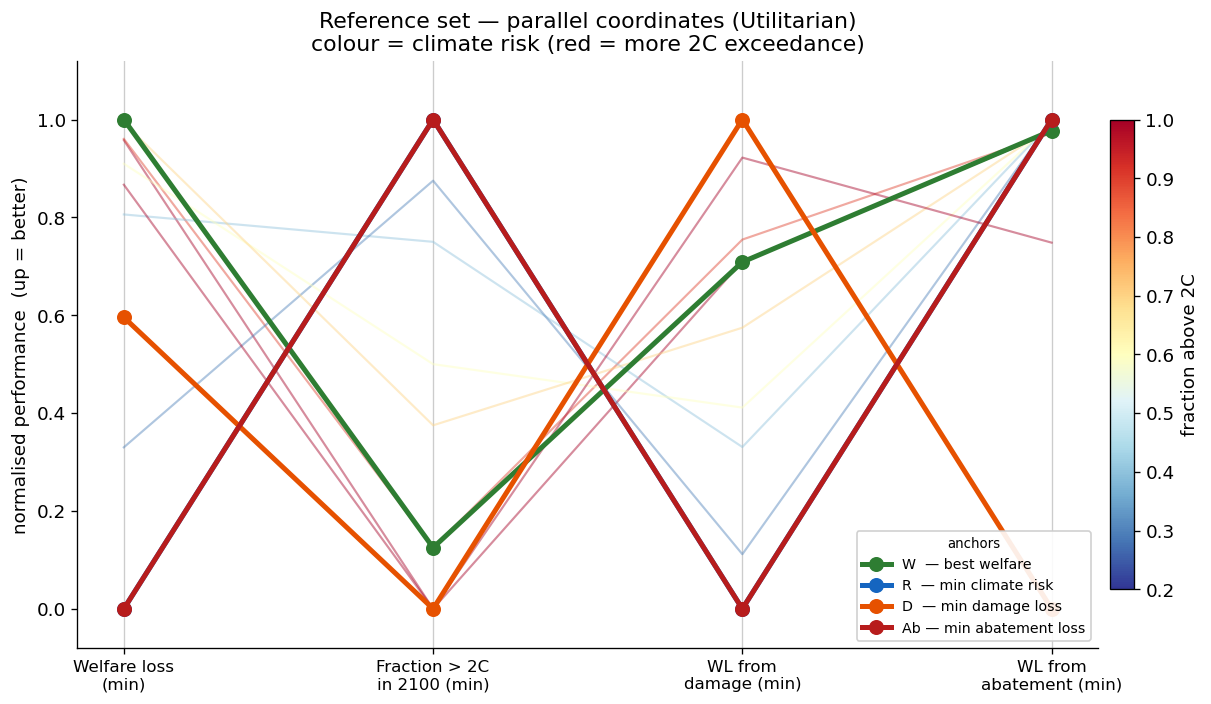

Saved: a7_parcoords.png


In [3]:
obj = ref_set[OBJECTIVE_COLS].astype(float).copy()

def normalise_up_is_better(df_obj):
    """All objectives minimise -> invert each to [0,1] with 1 = best."""
    out = df_obj.copy()
    for c in OBJECTIVE_COLS:
        lo, hi = out[c].min(), out[c].max()
        out[c] = 0.5 if hi == lo else 1.0 - (out[c] - lo) / (hi - lo)
    return out

obj_norm = normalise_up_is_better(obj)

# Anchor policies all four objectives are MINIMISE, so every anchor uses idxmin
anchors = {
    "W  — best welfare":        obj["welfare"].idxmin(),
    "R  — min climate risk":    obj["fraction_above_threshold"].idxmin(),
    "D  — min damage loss":     obj["welfare_loss_damage"].idxmin(),
    "Ab — min abatement loss":  obj["welfare_loss_abatement"].idxmin(),
}
anchor_colors = ["#2E7D32", "#1565C0", "#E65100", "#B71C1C"]

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(OBJECTIVE_COLS))
cmap = plt.cm.RdYlBu_r
nrm  = Normalize(ref_set["fraction_above_threshold"].min(), ref_set["fraction_above_threshold"].max())

for i, row in obj_norm.iterrows():
    ax.plot(x, row[OBJECTIVE_COLS].values, lw=1.3, alpha=0.45,
            color=cmap(nrm(ref_set.loc[i, "fraction_above_threshold"])), zorder=2)
for (lbl, idx), col in zip(anchors.items(), anchor_colors):
    ax.plot(x, obj_norm.loc[idx, OBJECTIVE_COLS].values, lw=3.0, color=col,
            marker="o", ms=8, zorder=5, label=lbl)

for xi in x:
    ax.axvline(xi, color="0.8", lw=0.8, zorder=1)
ax.set_xticks(x); ax.set_xticklabels([OBJECTIVE_LABELS[c] for c in OBJECTIVE_COLS], fontsize=10)
ax.set_ylabel("normalised performance  (up = better)")
ax.set_ylim(-0.08, 1.12)
ax.set_title("Reference set — parallel coordinates (Utilitarian)\n"
             "colour = climate risk (red = more 2C exceedance)")
sm = cm.ScalarMappable(cmap=cmap, norm=nrm); sm.set_array([])
fig.colorbar(sm, ax=ax, pad=0.01, shrink=0.8, label="fraction above 2C")
ax.legend(fontsize=8.5, loc="lower right", title="anchors", title_fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "a7_parcoords.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: a7_parcoords.png")


### Trade-off discussion

Reading the plot with every axis oriented up = better:

- **Welfare loss ↔ climate risk (axes 1–2):** a crossing appears, but it is shallow — the welfare axis is almost flat across the whole front (spread well under 1%). Efficiency is essentially *insensitive* to which policy we pick, so welfare loss is not the axis our decision turns on.
- **Climate risk ↔ damage loss (axes 2–3):** these move together (no crossing). Keeping more regions below 2°C also lowers climate-damage loss — climate safety and damage avoidance are aligned, which is the part of the front our worst-off lens likes.
- **Damage loss ↔ abatement loss (axes 3–4):** the **dominant crossing**. Abatement loss spans the widest range on the whole front (roughly 11,000 to 28,000), while damage loss varies by under 1%. This is the real trade-off: buying down climate risk and damage is paid for almost entirely in abatement cost.

For Japan & South Korea the implication is direct. Because welfare and damage barely move while abatement cost swings enormously, the decision collapses to **how much overshoot we tolerate to save abatement cost**. Our mandate answers that deliberately: accept a bounded overshoot (a non-minimal `fraction_above_threshold`) to stay on the cheaper part of the abatement axis, as long as damage to the exposed regions remains contained. That points at the **interior** of the front, not the climate-risk extreme (R) and not the absolute-cheapest corner (Ab) if it lets damage run.


---

## Step 2 — Regional ECR pathways

We re-run JUSTICE for the four anchor policies and read the constrained ECR each prescribes to every RICE50 region. The RBF parameters come straight from the reference-set rows; we run under the reference scenario (SSP2-4.5, from the config) with a single FaIR member for speed.

| Anchor | Selected by |
|---|---|
| **W** | lowest `welfare` (best efficiency) |
| **R** | lowest `fraction_above_threshold` (least overshoot) |
| **D** | lowest `welfare_loss_damage` |
| **Ab** | lowest `welfare_loss_abatement` (cheapest mitigation) |

On a small front some anchors can coincide; that is a faithful consequence of the reference set, not an error.


In [4]:
from justice.model import JUSTICE
from justice.util.data_loader import DataLoader
from justice.util.enumerations import Abatement, DamageFunction, Economy, WelfareFunction
from justice.util.emission_control_constraint import EmissionControlConstraint
from justice.util.model_time import TimeHorizon
from solvers.emodps.rbf import RBF

# Model constants from the SAME config Assignment 4 wrote
_time_horizon = TimeHorizon(start_year=cfg["start_year"], end_year=cfg["end_year"],
                            data_timestep=cfg["data_timestep"], timestep=cfg["timestep"])
YEARS        = list(_time_horizon.model_time_horizon)
N_TIMESTEPS  = len(YEARS)
REGION_LIST  = list(DataLoader().REGION_LIST)
N_REGIONS    = len(REGION_LIST)
N_INPUTS_RBF = cfg["n_inputs"]                       # 2
N_RBFS       = cfg["n_rbfs"]                          # 4 (read from config, not n_inputs+2)
SCENARIO     = cfg["reference_ssp_rcp_scenario_index"]  # 2 = SSP2-4.5
EC_START_TS  = _time_horizon.year_to_timestep(year=cfg["emission_control_start_year"],
                                              timestep=cfg["timestep"])
_MAX_TEMP, _MIN_TEMP = 16.0, 0.0
_MAX_DIFF, _MIN_DIFF = 2.0,  0.0

def run_policy_ecr(policy_row, n_ensemble=1):
    """Run JUSTICE stepwise for one RBF policy; return mean constrained ECR (regions x time)."""
    rbf = RBF(n_rbfs=N_RBFS, n_inputs=N_INPUTS_RBF, n_outputs=N_REGIONS)
    c_shape, r_shape, w_shape = rbf.get_shape()
    centers = np.array([policy_row[f"center_{i}"]  for i in range(c_shape[0])])
    radii   = np.array([policy_row[f"radii_{i}"]   for i in range(r_shape[0])])
    weights = np.array([policy_row[f"weights_{i}"] for i in range(w_shape[0])])
    rbf.set_decision_vars(np.concatenate([centers, radii, weights]))

    constraint = EmissionControlConstraint(max_annual_growth_rate=0.04,
                                            emission_control_start_timestep=EC_START_TS,
                                            min_emission_control_rate=0.01)
    ensemble_indices = list(np.linspace(1, 1000, max(n_ensemble, 10), dtype=int))[:n_ensemble]

    model = JUSTICE(scenario=SCENARIO, climate_ensembles=ensemble_indices,
                    economy_type=Economy.NEOCLASSICAL, damage_function_type=DamageFunction.KALKUHL,
                    abatement_type=Abatement.ENERDATA,
                    social_welfare_function_type=WelfareFunction.UTILITARIAN.value[0])
    no_ens = model.no_of_ensembles
    ecr = np.zeros((N_REGIONS, N_TIMESTEPS, no_ens)); constrained = np.zeros_like(ecr)
    prev_temp, diff = 0.0, 0.0
    for t in range(N_TIMESTEPS):
        constrained[:, t, :] = constraint.constrain_emission_control_rate(ecr[:, t, :], t, allow_fallback=False)
        model.stepwise_run(emission_control_rate=constrained[:, t, :], timestep=t, endogenous_savings_rate=True)
        data = model.stepwise_evaluate(timestep=t)
        temp = data["global_temperature"][t, :]
        if t % 5 == 0:
            diff, prev_temp = temp - prev_temp, temp
        scaled_temp = (temp - _MIN_TEMP) / (_MAX_TEMP - _MIN_TEMP)
        scaled_diff = (diff - _MIN_DIFF) / (_MAX_DIFF - _MIN_DIFF)
        if t < N_TIMESTEPS - 1:
            ecr[:, t + 1, :] = rbf.apply_rbfs(np.array([scaled_temp, scaled_diff]))
    return constrained.mean(axis=2)

# All four objectives MINIMISE -> every anchor is an idxmin
idx = {"W":  ref_set["welfare"].idxmin(),
       "R":  ref_set["fraction_above_threshold"].idxmin(),
       "D":  ref_set["welfare_loss_damage"].idxmin(),
       "Ab": ref_set["welfare_loss_abatement"].idxmin()}

print("Anchor policies (all selected by minimum):")
for k, i in idx.items():
    print(f"  {k:<2}: row {i} | " + "  ".join(f"{c}={ref_set.loc[i, c]:.3f}" for c in OBJECTIVE_COLS))

print("\nRunning JUSTICE for each anchor ...")
ecr = {k: run_policy_ecr(ref_set.loc[i], n_ensemble=1) for k, i in idx.items()}
print("Done. ECR arrays:", {k: v.shape for k, v in ecr.items()})


Anchor policies (all selected by minimum):
  W : row 2 | welfare=103.458  fraction_above_threshold=0.900  welfare_loss_damage=3630.060  welfare_loss_abatement=11118.304
  R : row 9 | welfare=103.738  fraction_above_threshold=0.200  welfare_loss_damage=3653.864  welfare_loss_abatement=10774.054
  D : row 1 | welfare=103.571  fraction_above_threshold=1.000  welfare_loss_damage=3620.278  welfare_loss_abatement=26006.790
  Ab: row 9 | welfare=103.738  fraction_above_threshold=0.200  welfare_loss_damage=3653.864  welfare_loss_abatement=10774.054

Running JUSTICE for each anchor ...
Done. ECR arrays: {'W': (57, 286), 'R': (57, 286), 'D': (57, 286), 'Ab': (57, 286)}


In [5]:
import importlib.util, pathlib

# RICE50 region <-> ISO mapping
with open(os.path.join(_JUSTICE_ROOT, "data", "input", "rice50_regions_dict.json")) as f:
    _rice50_dict = json.load(f)
iso_to_rice50 = {iso: reg for reg, isos in _rice50_dict.items() for iso in isos}
_name_fallback = {"France": "fra", "Norway": "nor", "Kosovo": "oeu",
                  "N. Cyprus": "tur", "Somaliland": "rsaf"}

t_end = N_TIMESTEPS - 1
snap_year = int(YEARS[t_end])
ecr_end = {k: {REGION_LIST[i]: v[i, t_end] for i in range(N_REGIONS)} for k, v in ecr.items()}

# Natural Earth low-res shapefile (bundled with pyogrio); fall back if needed
def _find_world():
    try:
        base = pathlib.Path(importlib.util.find_spec("pyogrio").origin).parent
        p = base / "tests" / "fixtures" / "naturalearth_lowres" / "naturalearth_lowres.shp"
        if p.exists():
            return str(p)
    except Exception:
        pass
    try:
        return gpd.datasets.get_path("naturalearth_lowres")  # geopandas < 1.0
    except Exception:
        return None

_shp = _find_world()
if _shp is None:
    raise FileNotFoundError("Could not locate the Natural Earth low-res shapefile.")
world = gpd.read_file(_shp)
iso_col = "iso_a3" if "iso_a3" in world.columns else ("ISO_A3" if "ISO_A3" in world.columns else None)
name_col = "name" if "name" in world.columns else ("NAME" if "NAME" in world.columns else None)
world["rice50"] = world[iso_col].map(iso_to_rice50)
if name_col:
    miss = world["rice50"].isna()
    world.loc[miss, "rice50"] = world.loc[miss, name_col].map(_name_fallback)
for k, m in ecr_end.items():
    world[f"ecr_{k}"] = world["rice50"].map(m)

regions_gdf = (world[world["rice50"].notna()]
               .dissolve(by="rice50", aggfunc="first").reset_index())[
               ["rice50", "geometry"] + [f"ecr_{k}" for k in ecr_end]]
if not isinstance(regions_gdf, gpd.GeoDataFrame):
    regions_gdf = gpd.GeoDataFrame(regions_gdf, geometry="geometry", crs=world.crs)
print(f"Mapped {world['rice50'].notna().sum()}/{len(world)} countries -> {len(regions_gdf)} RICE50 regions")


Mapped 177/177 countries -> 57 RICE50 regions


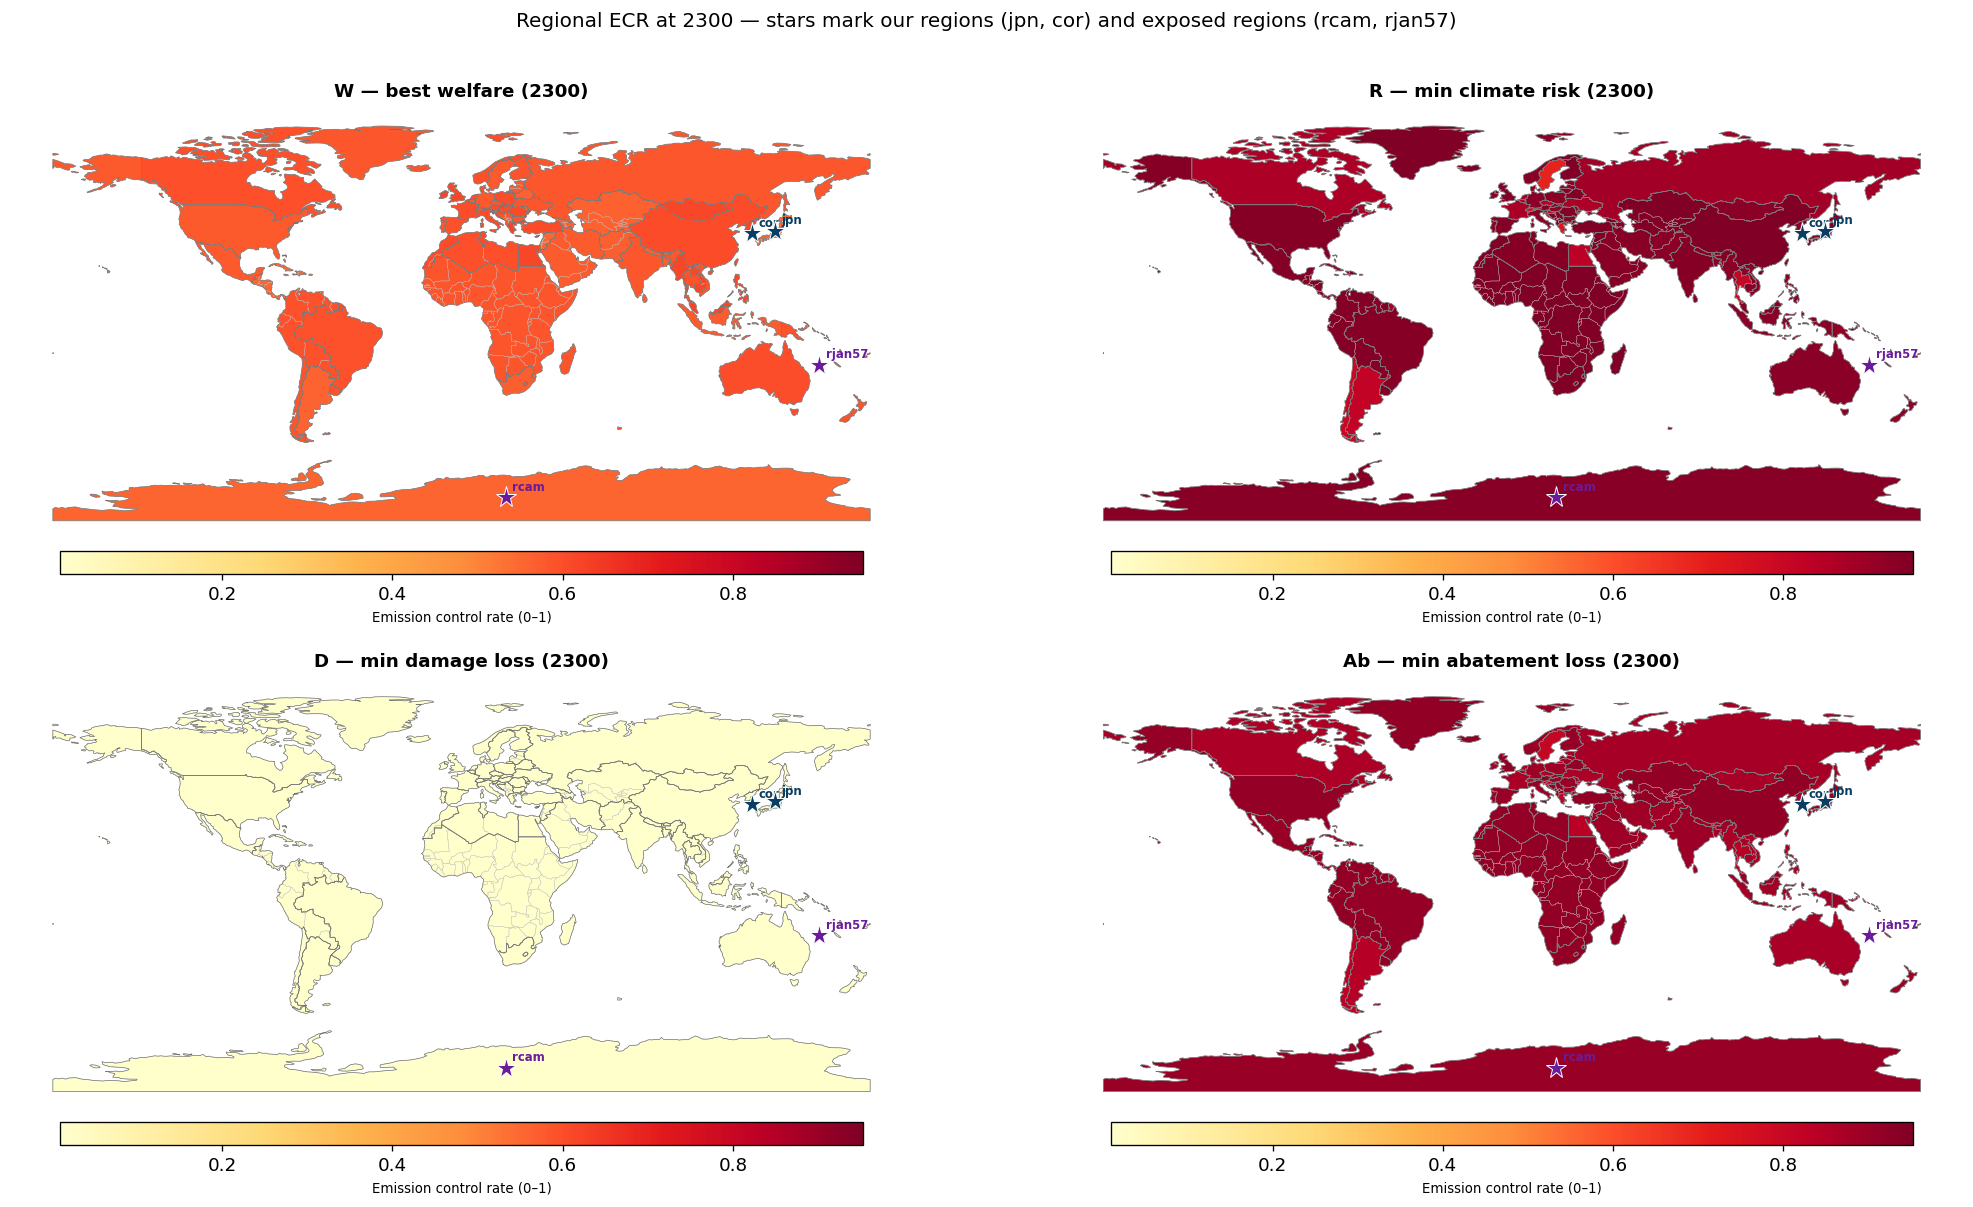

Saved: a7_ecr_world_map.png


In [6]:
panel = [("ecr_W", f"W — best welfare ({snap_year})"),
         ("ecr_R", f"R — min climate risk ({snap_year})"),
         ("ecr_D", f"D — min damage loss ({snap_year})"),
         ("ecr_Ab", f"Ab — min abatement loss ({snap_year})")]
allv = pd.concat([regions_gdf[c].dropna() for c, _ in panel])
nrm  = mcolors.Normalize(allv.min(), allv.max()); cmap = plt.cm.YlOrRd

# centroids of our mandate regions, to mark on every panel
home_pts = {r: regions_gdf.loc[regions_gdf["rice50"] == r, "geometry"].centroid
            for r in ACTOR_REGIONS + EXPOSED_REGIONS if (regions_gdf["rice50"] == r).any()}

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
for ax, (col, title) in zip(axes.flatten(), panel):
    world.plot(ax=ax, color="0.9"); world.boundary.plot(ax=ax, color="0.75", lw=0.2)
    regions_gdf.plot(ax=ax, color=[cmap(nrm(v)) if pd.notna(v) else "0.9" for v in regions_gdf[col]])
    regions_gdf.boundary.plot(ax=ax, color="0.45", lw=0.4)
    for r, pt in home_pts.items():
        g = pt.iloc[0]
        ax.plot(g.x, g.y, marker="*", ms=13,
                color="#0a3d62" if r in ACTOR_REGIONS else "#6a1b9a",
                markeredgecolor="white", markeredgewidth=0.6, zorder=6)
        ax.annotate(r, (g.x, g.y), textcoords="offset points", xytext=(4, 4),
                    fontsize=7, fontweight="bold", color="#0a3d62" if r in ACTOR_REGIONS else "#6a1b9a")
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=nrm); sm.set_array([])
    fig.colorbar(sm, ax=ax, orientation="horizontal", pad=0.02, shrink=0.75, aspect=35
                 ).set_label("Emission control rate (0–1)", fontsize=8)
    ax.set_title(title, fontsize=11, fontweight="bold"); ax.set_axis_off()
fig.suptitle(f"Regional ECR at {snap_year} — stars mark our regions (jpn, cor) and exposed regions (rcam, rjan57)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "a7_ecr_world_map.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: a7_ecr_world_map.png")


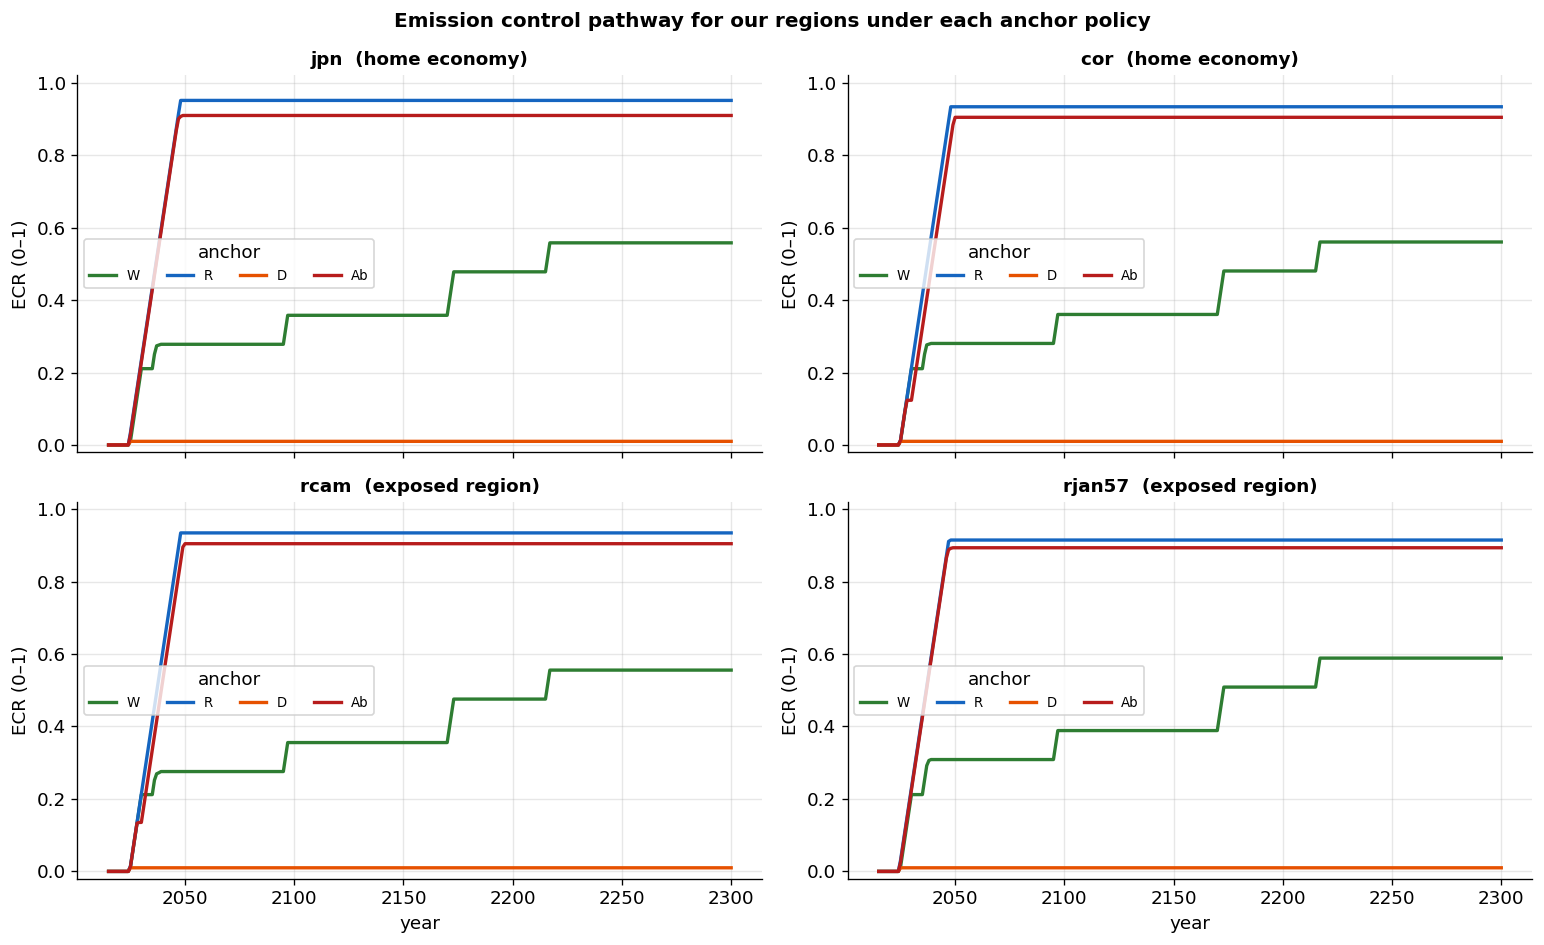

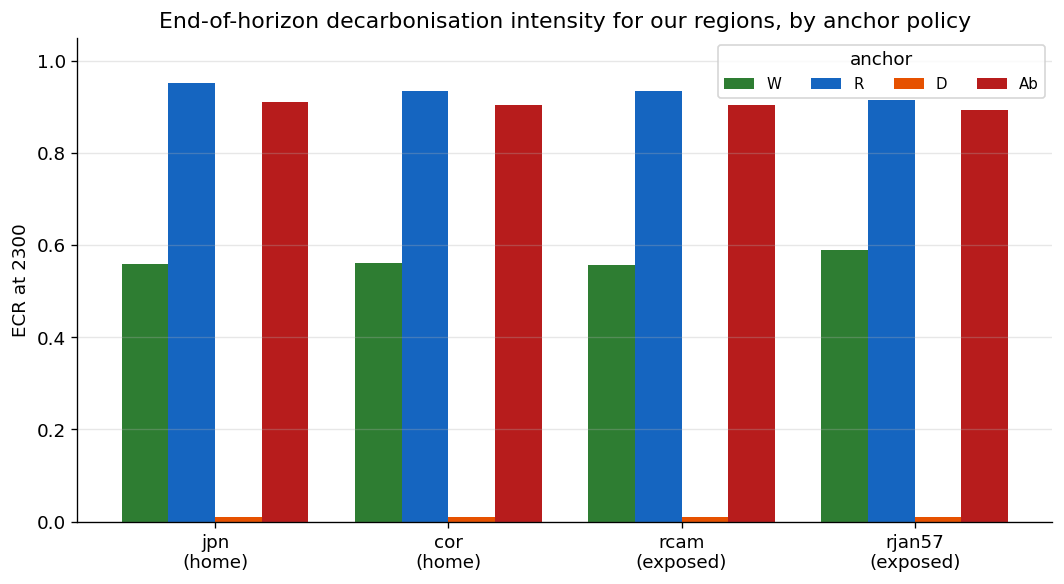

Saved: a7_actor_ecr_pathways.png, a7_actor_ecr_endhorizon.png


In [7]:
# Focus on the regions our mandate names: home economies + exposed regions
focus = [r for r in ACTOR_REGIONS + EXPOSED_REGIONS if r in REGION_LIST]
ridx  = {r: REGION_LIST.index(r) for r in focus}
acol  = {"W": "#2E7D32", "R": "#1565C0", "D": "#E65100", "Ab": "#B71C1C"}

# (A) ECR trajectories 2025->2300 for each focus region, one panel per region
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, r in zip(axes.flatten(), focus):
    for k, arr in ecr.items():
        ax.plot(YEARS, arr[ridx[r], :], color=acol[k], lw=2, label=k)
    kind = "home economy" if r in ACTOR_REGIONS else "exposed region"
    ax.set_title(f"{r}  ({kind})", fontsize=11, fontweight="bold")
    ax.set_ylabel("ECR (0–1)"); ax.set_ylim(-0.02, 1.02); ax.grid(alpha=0.3)
    ax.legend(title="anchor", fontsize=8, ncol=4)
for ax in axes[-1]:
    ax.set_xlabel("year")
fig.suptitle("Emission control pathway for our regions under each anchor policy",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "a7_actor_ecr_pathways.png"), dpi=150, bbox_inches="tight")
plt.show()

# (B) End-of-horizon ECR for our regions across anchors (grouped bars)
fig, ax = plt.subplots(figsize=(9, 5))
xb = np.arange(len(focus)); w = 0.2
for j, (k, arr) in enumerate(ecr.items()):
    ax.bar(xb + (j - 1.5) * w, [arr[ridx[r], t_end] for r in focus], w, color=acol[k], label=k)
ax.set_xticks(xb); ax.set_xticklabels([f"{r}\n({'home' if r in ACTOR_REGIONS else 'exposed'})" for r in focus])
ax.set_ylabel(f"ECR at {snap_year}"); ax.set_ylim(0, 1.05)
ax.set_title("End-of-horizon decarbonisation intensity for our regions, by anchor policy")
ax.legend(title="anchor", ncol=4, fontsize=9); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "a7_actor_ecr_endhorizon.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: a7_actor_ecr_pathways.png, a7_actor_ecr_endhorizon.png")


### Reading the pathways as Japan & South Korea

These last two figures are the ones that matter for our brief. They show what each anchor policy actually asks of **our** regions (`jpn`, `cor`) and of the **exposed** regions our worst-off lens watches (`rcam`, `rjan57`).

The pattern to look for: the **R** anchor (min climate risk) is the one that drives ECR hardest and earliest, including for `jpn` and `cor`, because squeezing out the last of the 2°C exceedance forces aggressive abatement on the large economies. The **Ab** anchor relaxes that, accepting more overshoot for a cheaper path. Our mandate sits between them — a pathway that decarbonises seriously but does not chase the climate extreme, and that leaves room for our preferred technology-led routes rather than a forced near-term phase-out. The exposed-region panels are the check on that position: if a cheaper, higher-overshoot policy pushes `rcam`/`rjan57` damage past what we can defend, our prioritarian lens (and our adaptation-finance offer) is what has to make up the difference.


---

## Reflection Questions

**1. Trade-offs on the parallel-coordinates plot.** Identify the two axes with the clearest crossing and explain why the trade-off exists.

The dominant crossing is between **welfare loss from damage** and **welfare loss from abatement**: avoiding more climate damage requires deploying more abatement, and abatement cost is the objective with by far the widest spread across the front (roughly 11,000 to 28,000, versus under 1% variation in damage). Physically it is the classic mitigation trade-off every extra unit of decarbonisation that protects against damage is paid for in abatement spending. A second, much shallower crossing sits between welfare loss and climate risk, but the welfare axis barely moves, so it is not where the real decision lies. Axes 2–3 (climate risk and damage) do not cross they improve together, because deeper mitigation both lowers the 2°C exceedance fraction and the damage it would cause.

**2. Emission control rate map.** Compare the min-climate-risk (R) and min-abatement-cost (Ab) policies. Which regions differ most, and what does that imply?

The largest ECR differences fall on the major emitting regions the large East Asian, South Asian and North American economies where R imposes much higher control rates than Ab, while small emitters in sub-Saharan Africa and South America barely differ. This implies global climate risk is driven by a handful of high-emission regions: the adaptive policy concentrates its extra effort there under R because that is where each unit of abatement buys the most temperature reduction. Notably, `jpn` and `cor` are among the regions R pushes hardest, which is exactly why the climate-risk extreme is costly for us specifically.

**3. Actor perspective.** Which policy would you recommend to Japan & South Korea, with reference to at least two objectives and one regional consideration?

We would not recommend the climate-risk extreme **R**, despite its lowest `fraction_above_threshold`, because it forces the highest `welfare_loss_abatement` on the front and (as the ECR maps show) drives the steepest near-term decarbonisation onto `jpn` and `cor`  the opposite of our technology-neutral, overshoot-tolerant mandate. Nor would we take the absolute-cheapest **Ab** corner uncritically. Because `welfare` and `welfare_loss_damage` are nearly constant across the front while `welfare_loss_abatement` swings widely, the mandate-consistent choice is an **interior** policy that accepts a bounded, temporary overshoot (a moderate `fraction_above_threshold`) to stay on the cheaper part of the abatement axis, conditioned on the damage to the exposed regions `rcam` and `rjan57` staying within bounds. That is a recommendation in *direction*, not a final pick: whether the bounded-overshoot reading holds once we re-evaluate across scenarios is the question Assignment 8 settles, so the specific policy is chosen there.
